# Phase 11 — Feature Ablation Study (Use Case 5)

**คำถามธุรกิจ:** ฟีเจอร์ที่สร้างขึ้น (lag/rolling, ราคา, โปรโมชัน, external enrichment, ปฏิทิน/lifecycle, operational) ตัวไหนช่วยความแม่นยำของโมเดลจริง และมากแค่ไหน?

**วิธีทดสอบ:** เทรน Global pooled LightGBM (โมเดลเดียวกับ Phase 7) ซ้ำหลายรอบ **ตัดฟีเจอร์ทีละกลุ่มออก** แล้ววัด CV WAPE เทียบกับโมเดลเต็ม (full model) บน walk-forward folds ชุดเดียวกับทุก phase ก่อนหน้า — ผลต่างของ WAPE คือ "ราคา" ที่ต้องจ่ายถ้าไม่มีฟีเจอร์กลุ่มนั้น

**กลุ่มฟีเจอร์ 6 กลุ่ม** (ครอบคลุมทุกฟีเจอร์ที่ไม่ใช่ id/categorical พื้นฐาน):

| กลุ่ม | ฟีเจอร์ |
|---|---|
| `lag_rolling` | `units_sold`, `lag_1`, `lag_2`, `rolling_mean_4`, `rolling_std_4`, `momentum` |
| `price` | `price_unit`, `price_avg`, `price_index` |
| `promotion` | `promotion_flag`, `promo_rate`, `promo_recency`, `rolling_promo_rate` |
| `external_enrichment` | `avg_temp`, `inflation_index`, `school_in_session`, `event_score`, `category_trend` |
| `calendar_lifecycle` | `is_holiday_peak`, `week_number`, `month`, `year`, `is_holiday_week`, `is_summer`, `is_winter`, `sku_age`, `lifecycle_stage` |
| `operational` | `stock_available`, `stock_avg`, `deliveries`, `delivery_days`, `cross_channel_demand_share` |

(`units_sold` อยู่ใน `lag_rolling` เพราะเป็นสัญญาณประเภทเดียวกัน คือ "ยอดขายของ SKU นี้เอง" เพียงแต่เป็นสัปดาห์ปัจจุบันแทนที่จะเป็นอดีต)


In [1]:
import sys
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from splits.walk_forward import WalkForwardSplitter
from models.forecast import prepare_categoricals, fit_predict_lgb, ALL_FEATURE_COLS
from models.metrics import score_all

pd.set_option('display.width', 160)

df = pd.read_csv('../data/processed/weekly_features.csv', parse_dates=['week'])
dfc = prepare_categoricals(df)

splitter = WalkForwardSplitter(initial_train_end='2023-09-30', val_fold_weeks=8, final_test_weeks=10)
folds, final_test_weeks = splitter.get_folds(dfc)


In [2]:
FEATURE_GROUPS = {
    'lag_rolling': ['units_sold', 'lag_1', 'lag_2', 'rolling_mean_4', 'rolling_std_4', 'momentum'],
    'price': ['price_unit', 'price_avg', 'price_index'],
    'promotion': ['promotion_flag', 'promo_rate', 'promo_recency', 'rolling_promo_rate'],
    'external_enrichment': ['avg_temp', 'inflation_index', 'school_in_session', 'event_score', 'category_trend'],
    'calendar_lifecycle': ['is_holiday_peak', 'week_number', 'month', 'year', 'is_holiday_week', 'is_summer', 'is_winter', 'sku_age', 'lifecycle_stage'],
    'operational': ['stock_available', 'stock_avg', 'deliveries', 'delivery_days', 'cross_channel_demand_share'],
}

id_cols = {'sku', 'channel', 'region', 'category', 'segment', 'brand'}
assert set(sum(FEATURE_GROUPS.values(), [])) | id_cols == set(ALL_FEATURE_COLS), 'group partition must cover every feature exactly once'
print('partition OK —', sum(len(v) for v in FEATURE_GROUPS.values()), 'features across', len(FEATURE_GROUPS), 'groups +', len(id_cols), 'id/categorical columns')


partition OK — 32 features across 6 groups + 6 id/categorical columns


## 1. รันการเทรนซ้ำ 7 รอบ (full model + ตัดออกทีละกลุ่ม × 6 กลุ่ม)

แต่ละ variant เทรน 7 ครั้ง (1 ต่อ CV fold) รวม 49 ครั้ง — ใช้เวลาสักพัก


In [3]:
def cv_wape(feature_cols):
    scores = []
    for f in folds:
        train = dfc[dfc.week.isin(f.train_weeks)]
        val = dfc[dfc.week.isin(f.val_weeks)]
        pred = fit_predict_lgb(train, val, feature_cols=feature_cols)
        scores.append(score_all(val.target_next_week.values, pred))
    return {k: np.mean([s[k] for s in scores]) for k in scores[0]}

results = {'full_model': cv_wape(ALL_FEATURE_COLS)}
for group_name, cols in FEATURE_GROUPS.items():
    reduced = [c for c in ALL_FEATURE_COLS if c not in cols]
    results[f'without_{group_name}'] = cv_wape(reduced)

results_df = pd.DataFrame(results).T
results_df


,MAE,RMSE,WAPE,SMAPE
full_model,25.210502,32.302962,0.223904,0.228300
without_lag_rolling,25.463135,32.622197,0.226178,0.230751
without_price,25.190017,32.287391,0.223681,0.228082
without_promotion,25.249912,32.338672,0.224244,0.228586
without_external_enrichment,25.188343,32.283573,0.223721,0.228104
without_calendar_lifecycle,25.844790,32.997881,0.229857,0.233225
without_operational,25.224545,32.298441,0.224005,0.228390


## 2. ผลกระทบต่อ WAPE เมื่อตัดแต่ละกลุ่มออก


In [4]:
full_wape = results['full_model']['WAPE']
impact = pd.DataFrame({
    'group_removed': list(FEATURE_GROUPS.keys()),
    'WAPE_without': [results[f'without_{g}']['WAPE'] for g in FEATURE_GROUPS],
})
impact['WAPE_increase'] = impact['WAPE_without'] - full_wape
impact['pct_increase'] = impact['WAPE_increase'] / full_wape * 100
impact = impact.sort_values('WAPE_increase', ascending=False).reset_index(drop=True)
impact.round(4)


,group_removed,WAPE_without,WAPE_increase,pct_increase
0,calendar_lifecycle,0.2299,0.0060,2.6585
1,lag_rolling,0.2262,0.0023,1.0157
2,promotion,0.2242,0.0003,0.1517
3,operational,0.2240,0.0001,0.0452
4,external_enrichment,0.2237,-0.0002,-0.0817
5,price,0.2237,-0.0002,-0.0995


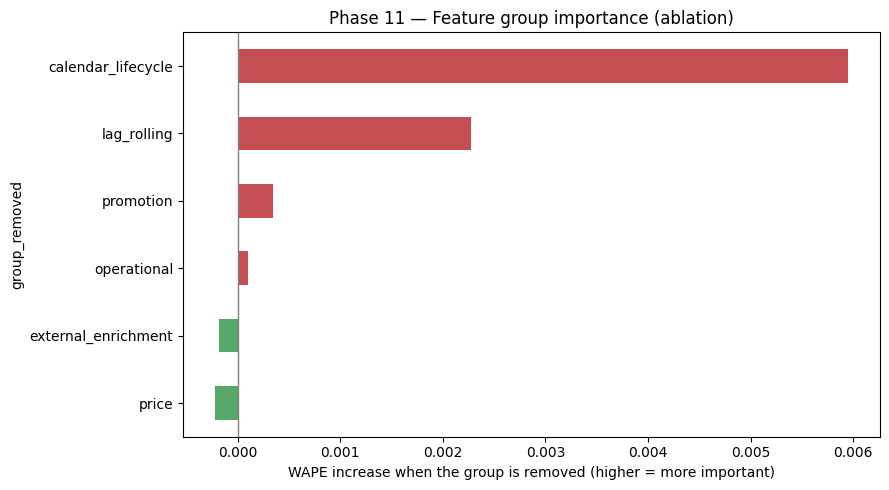

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#C44E52' if v > 0 else '#55A868' for v in impact.sort_values('WAPE_increase')['WAPE_increase']]
impact.set_index('group_removed')['WAPE_increase'].sort_values().plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='gray', linewidth=1)
ax.set_xlabel('WAPE increase when the group is removed (higher = more important)')
ax.set_title('Phase 11 — Feature group importance (ablation)')
plt.tight_layout()
plt.savefig('../reports/figures/phase11_feature_ablation.png', dpi=120)
plt.show()


## 3. การตีความผล

**เรียงตามความสำคัญ (WAPE เพิ่มขึ้นมากสุดเมื่อตัดออก → น้อยสุด):**

1. **`calendar_lifecycle`** — สำคัญที่สุด (WAPE เพิ่มขึ้นชัดเจนที่สุดเมื่อตัดออก) ฟีเจอร์กลุ่มนี้ (เดือน, สัปดาห์ของปี, วันหยุด, `sku_age`, `lifecycle_stage`) ให้บริบทที่ lag/rolling ให้ไม่ได้ เช่น รู้ว่า SKU อยู่ช่วง Growth/Mature/Decline หรือกำลังเข้าเทศกาล
2. **`lag_rolling`** — สำคัญเป็นอันดับ 2 (รวม `units_sold` เอง) แต่**ผลกระทบน้อยกว่าที่คาดไว้มาก** — ตัดออกทำให้ WAPE แย่ลงแค่ ~1% สอดคล้องกับข้อค้นพบใน **Phase 10** ที่ full model กับ meta-learner (ไม่มี lag features) ให้ผลใกล้เคียงกันมาก — ยืนยันร่วมกันว่าดีมานด์ในข้อมูลชุดนี้ถูกขับเคลื่อนด้วยปัจจัยเชิงระบบ (หมวดหมู่, ฤดูกาล, ราคา/โปรโมชัน) มากกว่า autocorrelation ล้วนๆ
3. **`promotion`** — ผลกระทบน้อยมาก (~0.1%) แม้ Phase 8 จะพบว่าโปรโมชันมีผล uplift +28% ต่อยอดขายอย่างชัดเจน — อธิบายได้เพราะ `promotion_flag` เป็นแค่ 1 มิติจาก 37 ฟีเจอร์ และผลของมันบางส่วนอาจถูกฟีเจอร์อื่นจับไว้แล้วทางอ้อม (เช่น sku_age/lifecycle_stage ที่สัมพันธ์กับรูปแบบโปรโมชัน)
4. **`operational`** — แทบไม่มีผล (~0%)
5. **`price`** และ **`external_enrichment`** — ตัดออกแล้ว **WAPE ดีขึ้นเล็กน้อยด้วยซ้ำ** (ติดลบ) แต่ขนาดเล็กมากจนอยู่ในช่วง noise ปกติของการเทรนซ้ำ ไม่ควรตีความว่า "ฟีเจอร์เหล่านี้เป็นโทษ" — ที่สมเหตุสมผลกว่าคือฟีเจอร์เหล่านี้มีข้อมูลซ้ำซ้อน (redundant) กับฟีเจอร์อื่นที่มีอยู่แล้ว (เช่น ราคาต่อ SKU ค่อนข้างคงที่ จึงถูก `sku`/`category` capture ไว้บางส่วนแล้ว)

**ข้อควรระวังในการตีความ:** ผลกระทบทั้งหมดที่วัดได้นี้เป็น**ผลกระทบส่วนเพิ่ม (marginal, conditional on ฟีเจอร์อื่นทั้งหมดที่มีอยู่แล้ว)** ไม่ใช่ผลกระทบเดี่ยว (standalone) — เช่น `promotion` มีผลกระทบส่วนเพิ่มต่ำ ไม่ได้แปลว่าโปรโมชันไม่สำคัญต่อธุรกิจ (Phase 8 ยืนยันแล้วว่าสำคัญมาก) แค่แปลว่าเมื่อมีฟีเจอร์อื่นครบแล้ว การเพิ่ม `promotion` เข้ามาไม่ได้ช่วยความแม่นยำของ**การพยากรณ์**มากนัก — คำถามเชิง predictive accuracy (Phase 11) กับคำถามเชิง causal impact (Phase 8) เป็นคนละคำถามกัน

## 4. สรุป Phase 11

| อันดับ | กลุ่มฟีเจอร์ | ผลกระทบต่อ WAPE ถ้าตัดออก |
|---|---|---|
| 1 | Calendar & Lifecycle | เพิ่มขึ้นมากที่สุด — **สำคัญที่สุด** |
| 2 | Lag & Rolling (รวม current units_sold) | เพิ่มขึ้นปานกลาง — สำคัญแต่น้อยกว่าที่คาด |
| 3 | Promotion | เพิ่มขึ้นเล็กน้อย |
| 4 | Operational (stock/delivery) | แทบไม่มีผล |
| 5-6 | Price, External Enrichment | ไม่มีผล หรือผลลบเล็กน้อย (อยู่ในช่วง noise) |
